# Exploración y descripción del Dataset: OASIS Cross-Sectional

El conjunto de datos utilizado proviene de la Open Access Series of Imaging Studies (OASIS), una base ampliamente utilizada en investigación sobre demencia y Alzheimer. Este dataset contiene imágenes de resonancia magnética cerebral estructural (T1-weighted MPRAGE) en formato NIfTI (.hdr/.img), organizadas por sujeto. En particular, el subconjunto analizado (disc1) incluye aproximadamente 20 sujetos (OAS1_0001 a OAS1_0020), aunque el repositorio completo contiene un total de 12 discos. Para cada sujeto se dispone de múltiples versiones de las imágenes: adquisiciones crudas (RAW), imágenes procesadas y promediadas (PROCESSED/SUBJ), registros en el espacio estándar Talairach (PROCESSED/T88) y segmentaciones de tejidos (FSL_SEG) que distinguen materia gris, materia blanca y líquido cefalorraquídeo. Las imágenes presentan una resolución típica de 256 × 256 × 160 vóxeles y están acompañadas de metadatos clínicos y demográficos relevantes, como edad, sexo, CDR (Clinical Dementia Rating), volumen intracraneal estimado (eTIV), volumen cerebral normalizado (nWBV) y factor de escala (ASF).


## 0. Importaciones

In [2]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import glob, os
import pandas as pd
from scipy import stats
from dotenv import load_dotenv
import seaborn as sns
from scipy.stats import skew

env_path = os.path.join(os.getcwd(), '.env')
if not os.path.isfile(env_path):
    env_path = os.path.join(os.getcwd(), 'Proyecto-Imagenes', '.env')

load_dotenv(env_path, override=True)

DISCS_ROOT = os.getenv('DATASET_ROOT')

DISC1_ROOT = os.path.join(DISCS_ROOT, 'disc1')

print(f"Discs root: {DISCS_ROOT}")
print(f"Disc1 root: {DISC1_ROOT}")

Discs root: C:\Users\Administrador\Desktop\Imagenes y vision\Proyecto\Proyecto-Imagenes\discs
Disc1 root: C:\Users\Administrador\Desktop\Imagenes y vision\Proyecto\Proyecto-Imagenes\discs\disc1


## 1. Entendimiento del CSV

### 1.1 Carga del CSV

In [4]:
csv_path = 'oasis_cross-sectional-5708aa0a98d82080.xlsx' 
df = pd.read_excel(csv_path)

df.head(10)


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN
5,OAS1_0006_MR1,F,R,24,NaN,NaN,NaN,NaN,1131,0.862,1.551,NaN
6,OAS1_0007_MR1,M,R,21,NaN,NaN,NaN,NaN,1516,0.830,1.157,NaN
7,OAS1_0009_MR1,F,R,20,NaN,NaN,NaN,NaN,1505,0.843,1.166,NaN
8,OAS1_0010_MR1,M,R,74,5.0,2.0,30.0,0.0,1636,0.689,1.073,NaN
9,OAS1_0011_MR1,F,R,52,3.0,2.0,30.0,0.0,1321,0.827,1.329,NaN


In [5]:
df.tail(10)

,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
426,OAS1_0202_MR2,F,R,23,NaN,NaN,NaN,NaN,1548,0.861,1.134,21.0
427,OAS1_0230_MR2,F,R,19,NaN,NaN,NaN,NaN,1577,0.849,1.113,24.0
428,OAS1_0236_MR2,F,R,20,NaN,NaN,NaN,NaN,1222,0.872,1.436,3.0
429,OAS1_0239_MR2,F,R,29,NaN,NaN,NaN,NaN,1438,0.822,1.221,40.0
430,OAS1_0249_MR2,F,R,28,NaN,NaN,NaN,NaN,1215,0.865,1.444,3.0
431,OAS1_0285_MR2,M,R,20,NaN,NaN,NaN,NaN,1469,0.847,1.195,2.0
432,OAS1_0353_MR2,M,R,22,NaN,NaN,NaN,NaN,1684,0.790,1.042,40.0
433,OAS1_0368_MR2,M,R,22,NaN,NaN,NaN,NaN,1580,0.856,1.111,89.0
434,OAS1_0379_MR2,F,R,20,NaN,NaN,NaN,NaN,1262,0.861,1.390,2.0
435,OAS1_0395_MR2,F,R,26,NaN,NaN,NaN,NaN,1283,0.834,1.368,39.0


### 1.2 Grafica de la distribución de clases

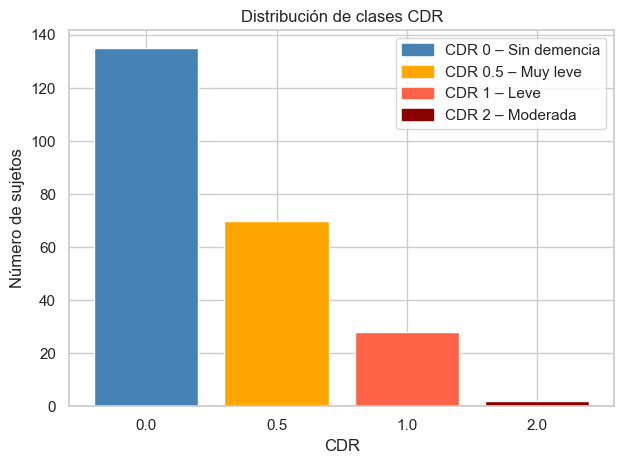

In [85]:
df_cdr = df.dropna(subset=['CDR'])
cdr_counts = df_cdr['CDR'].value_counts().sort_index()
colores = ['steelblue', 'orange', 'tomato', 'darkred']
etiquetas = {0.0: 'CDR 0 – Sin demencia', 0.5: 'CDR 0.5 – Muy leve', 1.0: 'CDR 1 – Leve', 2.0: 'CDR 2 – Moderada'}
bars = plt.bar([str(k) for k in cdr_counts.index],cdr_counts.values,color=colores[:len(cdr_counts)])
patches = [mpatches.Patch(color=colores[i], label=etiquetas[k]) for i, k in enumerate(cdr_counts.index)]

plt.legend(handles=patches, loc='upper right')
plt.title('Distribución de clases CDR')
plt.xlabel('CDR')
plt.ylabel('Número de sujetos')
plt.tight_layout()
plt.show()

### 1.3 Grafica de distribución por sexo

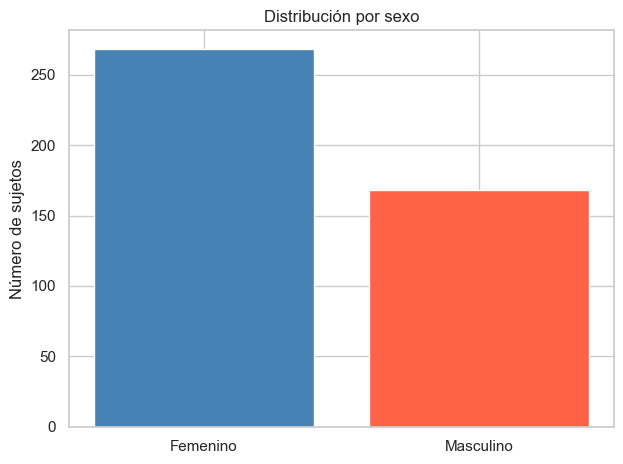

In [86]:
counts = df['M/F'].value_counts()

plt.bar(['Femenino', 'Masculino'], [counts.get('F', 0), counts.get('M', 0)], color=['steelblue', 'tomato'])
plt.title('Distribución por sexo')
plt.ylabel('Número de sujetos')
plt.tight_layout()
plt.show()

El CSV del dataset contiene metadatos clínicos y demográficos de 436 sujetos, de los cuales 235 tienen una evaluación de demencia mediante la escala CDR. Los 201 sujetos restantes son adultos jóvenes incluidos como sanos, para los cuales no se registró CDR ni otras variables como educación, MMSE o nivel socioeconómico. Por el lado de la distribución de sexo, se incluyen 26 mujeres y 168 hombres. Con respecto a la variable CDR, se observa un desbalance de clases significativo: 135 sujetos sin demencia (CDR = 0), 70 con deterioro muy leve (CDR = 0.5), 28 con deterioro leve (CDR = 1) y únicamente 2 con demencia moderada (CDR = 2). Este desbalance es relevante para el proyecto y será abordado durante el entrenamiento del modelo.

## 2. Entendimiento de las imagenes de OASIS-1

### 2.1 Distribución de sujetos por disco

El dataset OASIS Cross-Sectional está organizado en 12 discos. Cada disco contiene entre 34 y 38 sujetos. La siguiente tabla muestra cuántos sujetos hay en cada disco, para verificar el balance del dataset y el total de sujetos disponibles.

In [6]:
disc_names = sorted(
    [d for d in os.listdir(DISCS_ROOT)
     if os.path.isdir(os.path.join(DISCS_ROOT, d)) and d.startswith('disc')],
    key=lambda x: int(x.replace('disc', ''))
)

disc_counts = {}
for disc in disc_names:
    disc_path = os.path.join(DISCS_ROOT, disc)
    subjects = [s for s in os.listdir(disc_path)
                if os.path.isdir(os.path.join(disc_path, s))]
    disc_counts[disc] = len(subjects)

df_discs = pd.DataFrame({
    'Disco': list(disc_counts.keys()),
    'Num_sujetos': list(disc_counts.values())
})

display(df_discs)
print(f"\nTotal de sujetos en el dataset: {df_discs['Num_sujetos'].sum()}")
print(f"Promedio de sujetos por disco:  {df_discs['Num_sujetos'].mean():.1f}")


,Disco,Num_sujetos
0,disc1,38
1,disc2,38
2,disc3,36
3,disc4,35
4,disc5,38
5,disc6,37
6,disc7,38
7,disc8,35
8,disc9,35
9,disc10,35



Total de sujetos en el dataset: 435
Promedio de sujetos por disco:  36.2


### 2.2 Archivos por disco

Cada sujeto del dataset tiene cuatro tipos de imágenes en formato .hdr:

| Carpeta | Descripción |
|---|---|
| RAW/ | 4 adquisiciones crudas sin procesar (mpr-1 a mpr-4) |
| PROCESSED/MPRAGE/SUBJ_111/ | Volumen procesado y promediado, en espacio nativo del sujeto |
| PROCESSED/MPRAGE/T88_111/ | Volumen registrado espacio Talairach. |
| FSL_SEG/ | Segmentación de tejidos: materia gris, blanca y LCR |

A continuación se verifican los conteos de archivos .hdr por tipo y por sujeto, para detectar sujetos con datos faltantes.

#### 2.2.1 Extracción cantidad de imagenes RAW, SUBJ, T88 y SEG por sujeto

In [7]:

subject_rows = []

for disc in disc_names: 
    disc_path = os.path.join(DISCS_ROOT, disc)
    subjects = [s for s in os.listdir(disc_path) if os.path.isdir(os.path.join(disc_path, s))]
    
    for subj in subjects:
        sp = os.path.join(disc_path, subj)
        
        # cuántos .hdr hay de cada tipo para este sujeto
        raw_count = len(glob.glob(os.path.join(sp, 'RAW', '*.hdr')))
        subj_count = len(glob.glob(os.path.join(sp, 'PROCESSED', 'MPRAGE', 'SUBJ_111', '*.hdr')))
        t88_count = len(glob.glob(os.path.join(sp, 'PROCESSED', 'MPRAGE', 'T88_111', '*.hdr')))
        seg_count = len(glob.glob(os.path.join(sp, 'FSL_SEG', '*.hdr')))
        
        subject_rows.append({
            'Disco': disc,
            'Sujeto': subj,
            'RAW': raw_count,
            'SUBJ': subj_count,
            'T88': t88_count,
            'SEG': seg_count
        })

df_subjects = pd.DataFrame(subject_rows)


In [8]:
# Mostrar los primeros 10 sujetos
display(df_subjects.head(10))  

,Disco,Sujeto,RAW,SUBJ,T88,SEG
0,disc1,OAS1_0001_MR1,4,1,2,1
1,disc1,OAS1_0002_MR1,4,1,2,1
2,disc1,OAS1_0003_MR1,4,1,2,1
3,disc1,OAS1_0004_MR1,4,1,2,1
4,disc1,OAS1_0006_MR1,4,1,2,1
5,disc1,OAS1_0007_MR1,3,1,2,1
6,disc1,OAS1_0009_MR1,4,1,2,1
7,disc1,OAS1_0010_MR1,4,1,2,1
8,disc1,OAS1_0011_MR1,4,1,2,1
9,disc1,OAS1_0012_MR1,4,1,2,1


In [9]:
# Mostrar los ultimos 10 sujetos
display(df_subjects.tail(10)) 

,Disco,Sujeto,RAW,SUBJ,T88,SEG
425,disc12,OAS1_0448_MR1,4,1,2,1
426,disc12,OAS1_0449_MR1,4,1,2,1
427,disc12,OAS1_0450_MR1,4,1,2,1
428,disc12,OAS1_0451_MR1,3,1,2,1
429,disc12,OAS1_0452_MR1,3,1,2,1
430,disc12,OAS1_0453_MR1,3,1,2,1
431,disc12,OAS1_0454_MR1,3,1,2,1
432,disc12,OAS1_0455_MR1,3,1,2,1
433,disc12,OAS1_0456_MR1,4,1,2,1
434,disc12,OAS1_0457_MR1,3,1,2,1


#### 2.2.2 Grafica cantidad de imagenes RAW, SUBJ, T88 y SEG por sujeto

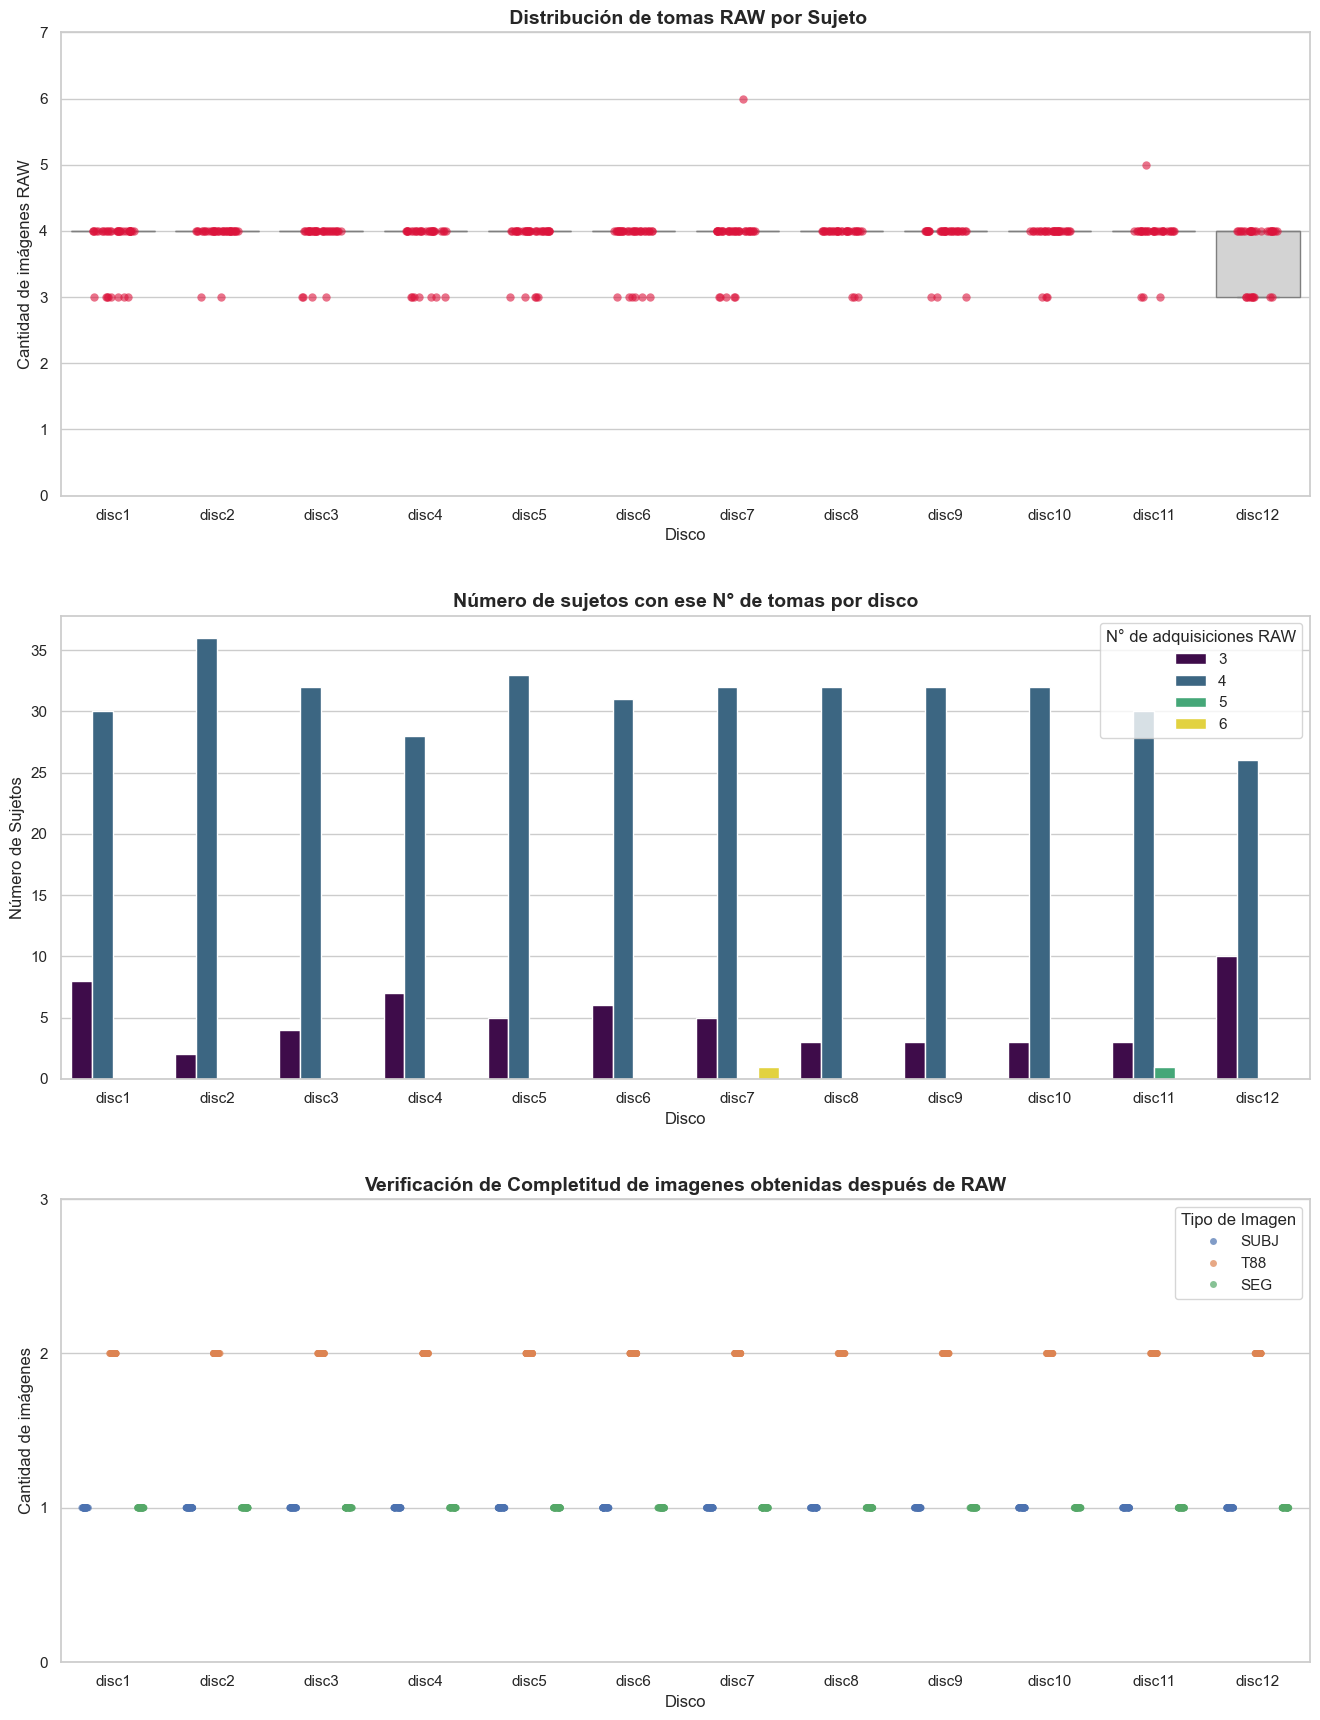

In [10]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# GRÁFICA 1 - Boxplot y Stripplot 

sns.boxplot(data=df_subjects, x='Disco', y='RAW', ax=axes[0], 
            color='lightgray', showfliers=False)
sns.stripplot(data=df_subjects, x='Disco', y='RAW', ax=axes[0], 
              color='crimson', alpha=0.6, jitter=0.2, size=6)

axes[0].set_title(' Distribución de tomas RAW por Sujeto', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cantidad de imágenes RAW', fontsize=12)
axes[0].set_yticks(range(0, df_subjects['RAW'].max() + 2))

# GRÁFICA 2 - Gráfico de Frecuencias 

sns.countplot(data=df_subjects, x='Disco', hue='RAW', ax=axes[1], palette='viridis')

axes[1].set_title('Número de sujetos con ese N° de tomas por disco', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Número de Sujetos', fontsize=12)
axes[1].legend(title='N° de adquisiciones RAW', loc='upper right')

# GRÁFICA 3 - Verificación de cuantas imagenes de cada tipo hay en cada sujeto

df_melt = df_subjects.melt(id_vars=['Disco', 'Sujeto'], 
                           value_vars=['SUBJ', 'T88', 'SEG'], 
                           var_name='Tipo de Imagen', value_name='Cantidad')

sns.stripplot(data=df_melt, x='Disco', y='Cantidad', hue='Tipo de Imagen', 
              ax=axes[2], dodge=True, jitter=0.1, alpha=0.7, size=5)

axes[2].set_title('Verificación de Completitud de imagenes obtenidas después de RAW', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Cantidad de imágenes', fontsize=12)
axes[2].set_yticks(range(0, 4)) 

plt.tight_layout(pad=3.0)
plt.show()

#### 2.2.3 Sujetos con más imagenes RAW que las indicadas por OASIS

In [11]:
outliers_especificos = df_subjects[
    ((df_subjects['Disco'] == 'disc7') & (df_subjects['RAW'] == 6)) |
    ((df_subjects['Disco'] == 'disc11') & (df_subjects['RAW'] == 5))
]

print("Sujetos atípicos encontrados:")
display(outliers_especificos[['Disco', 'Sujeto', 'RAW']])

Sujetos atípicos encontrados:


,Disco,Sujeto,RAW
242,disc7,OAS1_0254_MR1,6
382,disc11,OAS1_0401_MR1,5


Las gráficas demuestran que, aunque el dataset OASIS indica en su pagina la adquisición de 3 o 4 imágenes RAW de resonancia magnética por sujeto durante una misma sesión para luego promediarlas, existen algunas variaciones. Algunos pacientes tienen 3, la gran mayoría tiene 4, y unos pocos (exactamente dos sujetos) presentan casos atípicos de 5 o 6 adquisiciones, lo cual tiene sentido debido a la necesidad de repetir escaneos. Sin embargo, a pesar de estas diferencias en la cantidad de datos de entrada RAW, la tercera gráfica confirma que el proceso de estandarización es uniforme para todos los discos para cada uno de los sujetos, pues cuentan con exactamente 2 imágenes en el espacio T88 (las imagenes que se utilizaran en el entrenamiento), garantizando que no hay problemas de datos faltantes.

### 2.3 Volumenes de cada disco

#### 2.3.1 Extracción de volumenes RAW, SUBJ, T88 y SEG por sujeto

In [12]:
def load_first_hdr(pattern):
    files = sorted(glob.glob(pattern))
    if not files:
        return None, None, None
    try:
        img = nib.load(files[0])
        shape = img.shape
        spacing = tuple(round(float(v), 4) for v in img.header.get_zooms()[:3])
        return img, shape, spacing
    except Exception:
        return None, None, None

volume_rows = []
for disc in disc_names:
    disc_path = os.path.join(DISCS_ROOT, disc)
    subjects = sorted([s for s in os.listdir(disc_path) if os.path.isdir(os.path.join(disc_path, s))])

    for subj in subjects:
        sp = os.path.join(disc_path, subj)

        _, raw_shape, raw_sp = load_first_hdr(os.path.join(sp, 'RAW', '*.hdr'))
        _, t88_shape, t88_sp = load_first_hdr(os.path.join(sp, 'PROCESSED', 'MPRAGE', 'T88_111', '*masked_gfc.hdr'))
        _, seg_shape, seg_sp = load_first_hdr(os.path.join(sp, 'FSL_SEG', '*.hdr'))

        volume_rows.append({
            'Disco': disc,
            'Sujeto': subj,
            'RAW Shape': str(raw_shape) if raw_shape else 'Faltante',
            'RAW Spacing': str(raw_sp) if raw_sp else 'Faltante',
            'T88 Shape': str(t88_shape) if t88_shape else 'Faltante',
            'T88 Spacing': str(t88_sp) if t88_sp else 'Faltante',
            'SEG Shape': str(seg_shape) if seg_shape else 'Faltante',
            'SEG Spacing': str(seg_sp) if seg_sp else 'Faltante'
        })

df_volumes = pd.DataFrame(volume_rows)

In [13]:
display(df_volumes.head(10))

,Disco,Sujeto,RAW Shape,RAW Spacing,T88 Shape,T88 Spacing,SEG Shape,SEG Spacing
0,disc1,OAS1_0001_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
1,disc1,OAS1_0002_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
2,disc1,OAS1_0003_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
3,disc1,OAS1_0004_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
4,disc1,OAS1_0006_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
5,disc1,OAS1_0007_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
6,disc1,OAS1_0009_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
7,disc1,OAS1_0010_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
8,disc1,OAS1_0011_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
9,disc1,OAS1_0012_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"


In [14]:
display(df_volumes.tail(10)) 

,Disco,Sujeto,RAW Shape,RAW Spacing,T88 Shape,T88 Spacing,SEG Shape,SEG Spacing
425,disc12,OAS1_0448_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
426,disc12,OAS1_0449_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
427,disc12,OAS1_0450_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
428,disc12,OAS1_0451_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
429,disc12,OAS1_0452_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
430,disc12,OAS1_0453_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
431,disc12,OAS1_0454_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
432,disc12,OAS1_0455_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
433,disc12,OAS1_0456_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"
434,disc12,OAS1_0457_MR1,"(256, 256, 128, 1)","(1.0, 1.0, 1.25)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)","(176, 208, 176, 1)","(1.0, 1.0, 1.0)"


#### 2.3.2 Gráfica volumenes RAW, SUBJ, T88 y SEG por sujeto

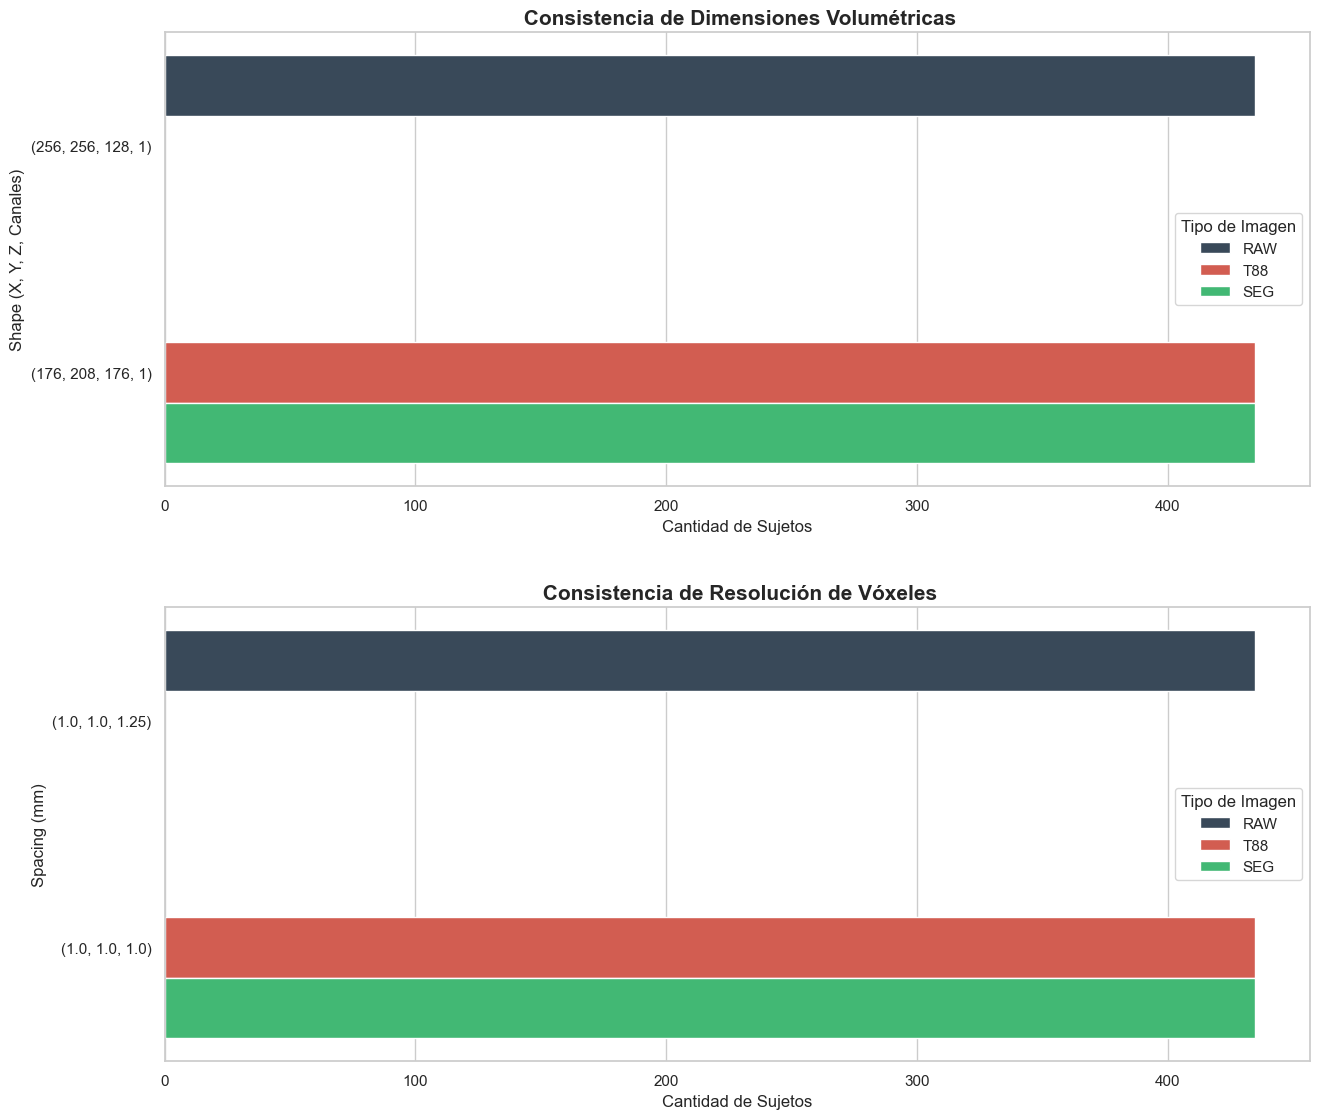

In [15]:
df_shapes_melt = df_volumes.melt(id_vars=['Disco', 'Sujeto'], 
                                 value_vars=['RAW Shape', 'T88 Shape', 'SEG Shape'], 
                                 var_name='Tipo de Imagen', value_name='Dimensiones ')

df_spacings_melt = df_volumes.melt(id_vars=['Disco', 'Sujeto'], 
                                   value_vars=['RAW Spacing', 'T88 Spacing', 'SEG Spacing'], 
                                   var_name='Tipo de Imagen', value_name='Resolución Espacial')

# "RAW Shape" -> "RAW"
df_shapes_melt['Tipo de Imagen'] = df_shapes_melt['Tipo de Imagen'].str.replace(' Shape', '')
df_spacings_melt['Tipo de Imagen'] = df_spacings_melt['Tipo de Imagen'].str.replace(' Spacing', '')

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# GRÁFICA 1: Estandarización de Dimensiones 

sns.countplot(data=df_shapes_melt, y='Dimensiones ', hue='Tipo de Imagen', 
              ax=axes[0], palette=['#34495e', '#e74c3c', '#2ecc71'])

axes[0].set_title(' Consistencia de Dimensiones Volumétricas', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Cantidad de Sujetos', fontsize=12)
axes[0].set_ylabel('Shape (X, Y, Z, Canales)', fontsize=12)

# GRÁFICA 2: Estandarización de Resoluciones 

sns.countplot(data=df_spacings_melt, y='Resolución Espacial', hue='Tipo de Imagen', 
              ax=axes[1], palette=['#34495e', '#e74c3c', '#2ecc71'])

axes[1].set_title(' Consistencia de Resolución de Vóxeles', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Cantidad de Sujetos', fontsize=12)
axes[1].set_ylabel('Spacing (mm)', fontsize=12)

plt.tight_layout(pad=3.0)
plt.show()

Todos los discos son compatibles entre sí en cuanto a dimensiones y resolución. Los volúmenes RAW tienen dimensiones 256 × 256 × 128 con resolución 1.0 × 1.0 × 1.25 mm, mientras que los T88 y SEG presentan 176 × 208 × 176 con resolución 1.0 × 1.0 × 1.0 mm, producto del registro al espacio Talairach.

#### Los siguientes analisis de los discos de OASIS, se realizaran utilizando la representación T88 masked GFC.

El archivo *_t88_masked_gfc.hdr* es el volumen resultado del pipeline completo de procesamiento de OASIS. Su nombre describe cada transformación aplicada:

| Parte del nombre | Transformación | Efecto práctico |
|---|---|---|
| `t88` | Registro al atlas Talairach | Todos los sujetos en el mismo espacio  |
| `masked` | Skull-stripping | Solo queda tejido cerebral sin cráneo, cuero cabelludo ni tejido graso |
| `gfc` | Corrección de campo de ganancia | Para homogeneidad de intensidad dentro del cerebro  |


### 2.4 Estadísticas de intensidad por disco

Para caracterizar las propiedades radiométricas de los volúmenes a lo largo de los 12 discos, se calculan las siguientes estadísticas sobre los píxeles de tejido del volumen T88 masked de cada sujeto:

- Media: indica el brillo general del volumen.
- Desviación estándar: variabilidad interna, contraste entre tejidos.
- Asimetría: sesgo de la distribución, positivo indica que la cola se extiende hacia intensidades altas.



#### 2.4.1 Extracción estadísticas de intensidad por disco para T88 masked GFC

In [16]:

stat_rows = []
for disc in disc_names:
    disc_path = os.path.join(DISCS_ROOT, disc)
    subjects = sorted([s for s in os.listdir(disc_path) if os.path.isdir(os.path.join(disc_path, s))])
    
    for subj in subjects:
        sp = os.path.join(disc_path, subj)
        t88_hdrs = sorted(glob.glob(os.path.join(sp, 'PROCESSED', 'MPRAGE', 'T88_111', '*masked_gfc.hdr')))
        
        if not t88_hdrs:
            continue
            
        try:
            data = nib.load(t88_hdrs[0]).get_fdata()
            px = data[data > 0].ravel() 
            
            stat_rows.append({
                'Disco': disc,
                'Sujeto': subj,
                'Media': round(float(np.mean(px)), 2),
                'StdDev': round(float(np.std(px)), 2),
                'Skewness': round(float(stats.skew(px)), 3)
            })
        except Exception:
            pass

df_disc_stats = pd.DataFrame(stat_rows)

print("Estadísticas de intensidad por disco T88 masked GFC /n")
resumen_stats = df_disc_stats.groupby('Disco')[['Media', 'StdDev', 'Skewness']].agg(['mean', 'std']).round(2)
display(resumen_stats)


Estadísticas de intensidad por disco T88 masked GFC /n


Media         StdDev        Skewness      
          mean    std    mean    std     mean   std
Disco                                              
disc1   901.76  11.43  351.68  38.65    -0.12  0.10
disc10  902.21  11.14  338.25  28.88    -0.13  0.09
disc11  906.34  12.00  334.36  27.04    -0.10  0.10
disc12  903.29  11.16  347.83  35.04    -0.12  0.10
disc2   909.38   8.17  344.83  39.88    -0.11  0.10
disc3   905.10  10.57  331.57  27.24    -0.09  0.12
disc4   904.10  10.23  342.71  40.15    -0.09  0.11
disc5   905.65  11.75  345.95  32.86    -0.13  0.09
disc6   903.68  13.33  346.34  35.11    -0.12  0.09
disc7   903.98  11.09  348.77  33.08    -0.12  0.09
disc8   904.28   9.73  358.72  32.87    -0.10  0.12
disc9   904.79   8.43  340.33  34.54    -0.10  0.13

#### 2.4.2 Graficos estadísticas de intensidad por disco para T88 masked GFC

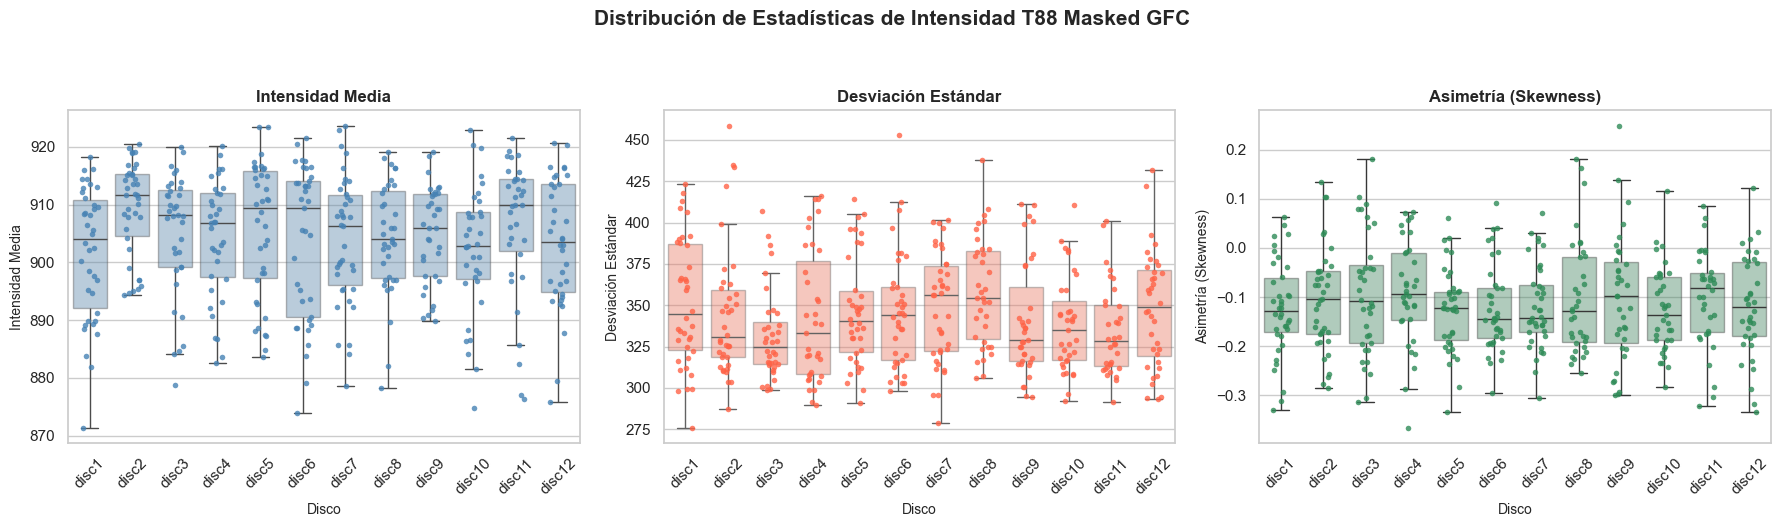

In [17]:

# GRÁFICAS DE DISTRIBUCIÓN DE INTENSIDADES 

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) 
fig.suptitle('Distribución de Estadísticas de Intensidad T88 Masked GFC', fontsize=15, fontweight='bold', y=1.05)

config_bp = [
    ('Media', 'steelblue', 'Intensidad Media'),
    ('StdDev', 'tomato', 'Desviación Estándar'),
    ('Skewness', 'seagreen', 'Asimetría (Skewness)')
]

for ax, (col, color, ylabel) in zip(axes, config_bp):
    sns.boxplot(data=df_disc_stats, x='Disco', y=col, ax=ax, 
                color=color, boxprops=dict(alpha=0.4), showfliers=False)
    sns.stripplot(data=df_disc_stats, x='Disco', y=col, ax=ax, 
                  color=color, alpha=0.8, jitter=0.2, size=4)
    
    ax.set_title(ylabel, fontsize=12, fontweight='bold')
    ax.set_xlabel('Disco', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- La grafica de la Media muestra que a pesar de la corrección GFC, el brillo base varia entre sujetos. Esto justifica hacer una estandarización en el preprocesamiento de los datos
- La grafica de la desviación estandar indica que hay bastante variabilidad de intensidades entre pacientes. 
- La grafica de la asimetría indica que la gran mayoria son negativos (la gran mayoría de los píxeles de la imagen son brillantes) lo cual es lo esperado.

### 2.6 Analisis del volumen T88 masked GFC

Para cada uno de los sujetos distribuidos en los 12 discos se recogen # vóxeles de tejido y su porcentaje sobre el volumen total

In [112]:
skull_strip_rows = []

for disc in disc_names:
    disc_path = os.path.join(DISCS_ROOT, disc)
    subjects = sorted([s for s in os.listdir(disc_path) 
                       if os.path.isdir(os.path.join(disc_path, s))])
    
    for subj in subjects:
        sp = os.path.join(disc_path, subj)
        hdrs = sorted(glob.glob(os.path.join(sp, 'PROCESSED', 'MPRAGE', 'T88_111', '*masked_gfc.hdr')))
        
        if not hdrs:
            continue 
            
        try:
            img = nib.load(hdrs[0])
            data = img.get_fdata()
            
            total_voxels = data.size
            tissue_voxels = int((data > 0).sum())
            pct_tissue = round(100 * tissue_voxels / total_voxels, 2)
            
            skull_strip_rows.append({
                'Disco': disc,
                'Sujeto': subj,
                'Voxeles Totales': total_voxels,
                'Voxeles Tejido': tissue_voxels,
                '% Tejido Cerebral': pct_tissue
            })
        except Exception:
            pass

df_skull = pd.DataFrame(skull_strip_rows)

print("Extracción de cráneo (Skull-Stripping) por disco \n")

resumen_skull = df_skull.groupby('Disco').agg({
    'Voxeles Totales': 'first', # vóxeles totales son idénticos para todos los sujetos
    'Voxeles Tejido': ['mean', 'min', 'max'],
    '% Tejido Cerebral': ['mean', 'min', 'max']
}).round(2)

display(resumen_skull)

Extracción de cráneo (Skull-Stripping) por disco 



Voxeles Totales Voxeles Tejido                   % Tejido Cerebral  \
                 first           mean      min      max              mean   
Disco                                                                       
disc1          6443008     1667264.00  1667264  1667264             25.88   
disc10         6443008     1667264.00  1667264  1667264             25.88   
disc11         6443008     1667263.94  1667262  1667264             25.88   
disc12         6443008     1667264.00  1667264  1667264             25.88   
disc2          6443008     1667264.00  1667264  1667264             25.88   
disc3          6443008     1667264.00  1667264  1667264             25.88   
disc4          6443008     1667101.20  1661566  1667264             25.88   
disc5          6443008     1667264.00  1667264  1667264             25.88   
disc6          6443008     1667264.00  1667264  1667264             25.88   
disc7          6443008     1667264.00  1667264  1667264             25.88   
disc8          6443008     1667264.00  1667264  1667264             25.88   
disc9          6443008     1667264.00  1667264  1667264             25.88   

                      
          min    max  
Disco                 
disc1   25.88  25.88  
disc10  25.88  25.88  
disc11  25.88  25.88  
disc12  25.88  25.88  
disc2   25.88  25.88  
disc3   25.88  25.88  
disc4   25.79  25.88  
disc5   25.88  25.88  
disc6   25.88  25.88  
disc7   25.88  25.88  
disc8   25.88  25.88  
disc9   25.88  25.88

Casi todos los sujetos tienen exactamente 1,667,264 vóxeles de tejido, lo que representa un 25.88% del volumen total. El skull-stripping de OASIS aplicó una máscara tridimensional estándar para aislar el cerebro en todo el dataset de manera uniforme. Las minimas diferencias en los discos 4 y 11 son anomalías de borde poco significativas.

## 3. Análisis imagenes de un sujeto

#### Para este analisis se tomará del disco 1 el sujeto 1

### 3.1 Visualización de las Imágenes RAW de un sujeto 

En el dataset OASIS, cada sesión de escaneo incluye sus tomas repetidas, como ya se vio anteriormente la mayoría tienen de 3 a 4. Estas repeticiones se realizan dentro de una misma sesión.

Estas tomas: 

- Son volúmenes 3D sin procesar, capturados consecutivamente en la misma sesión
- Cada volumen tiene dimensiones de 256 × 256 × 128 vóxeles con resolución de 1.0 × 1.0 × 1.25 mm
- Contienen ruido inherente al proceso de adquisición MRI y movimiento si el paciente se movió entre escaneos

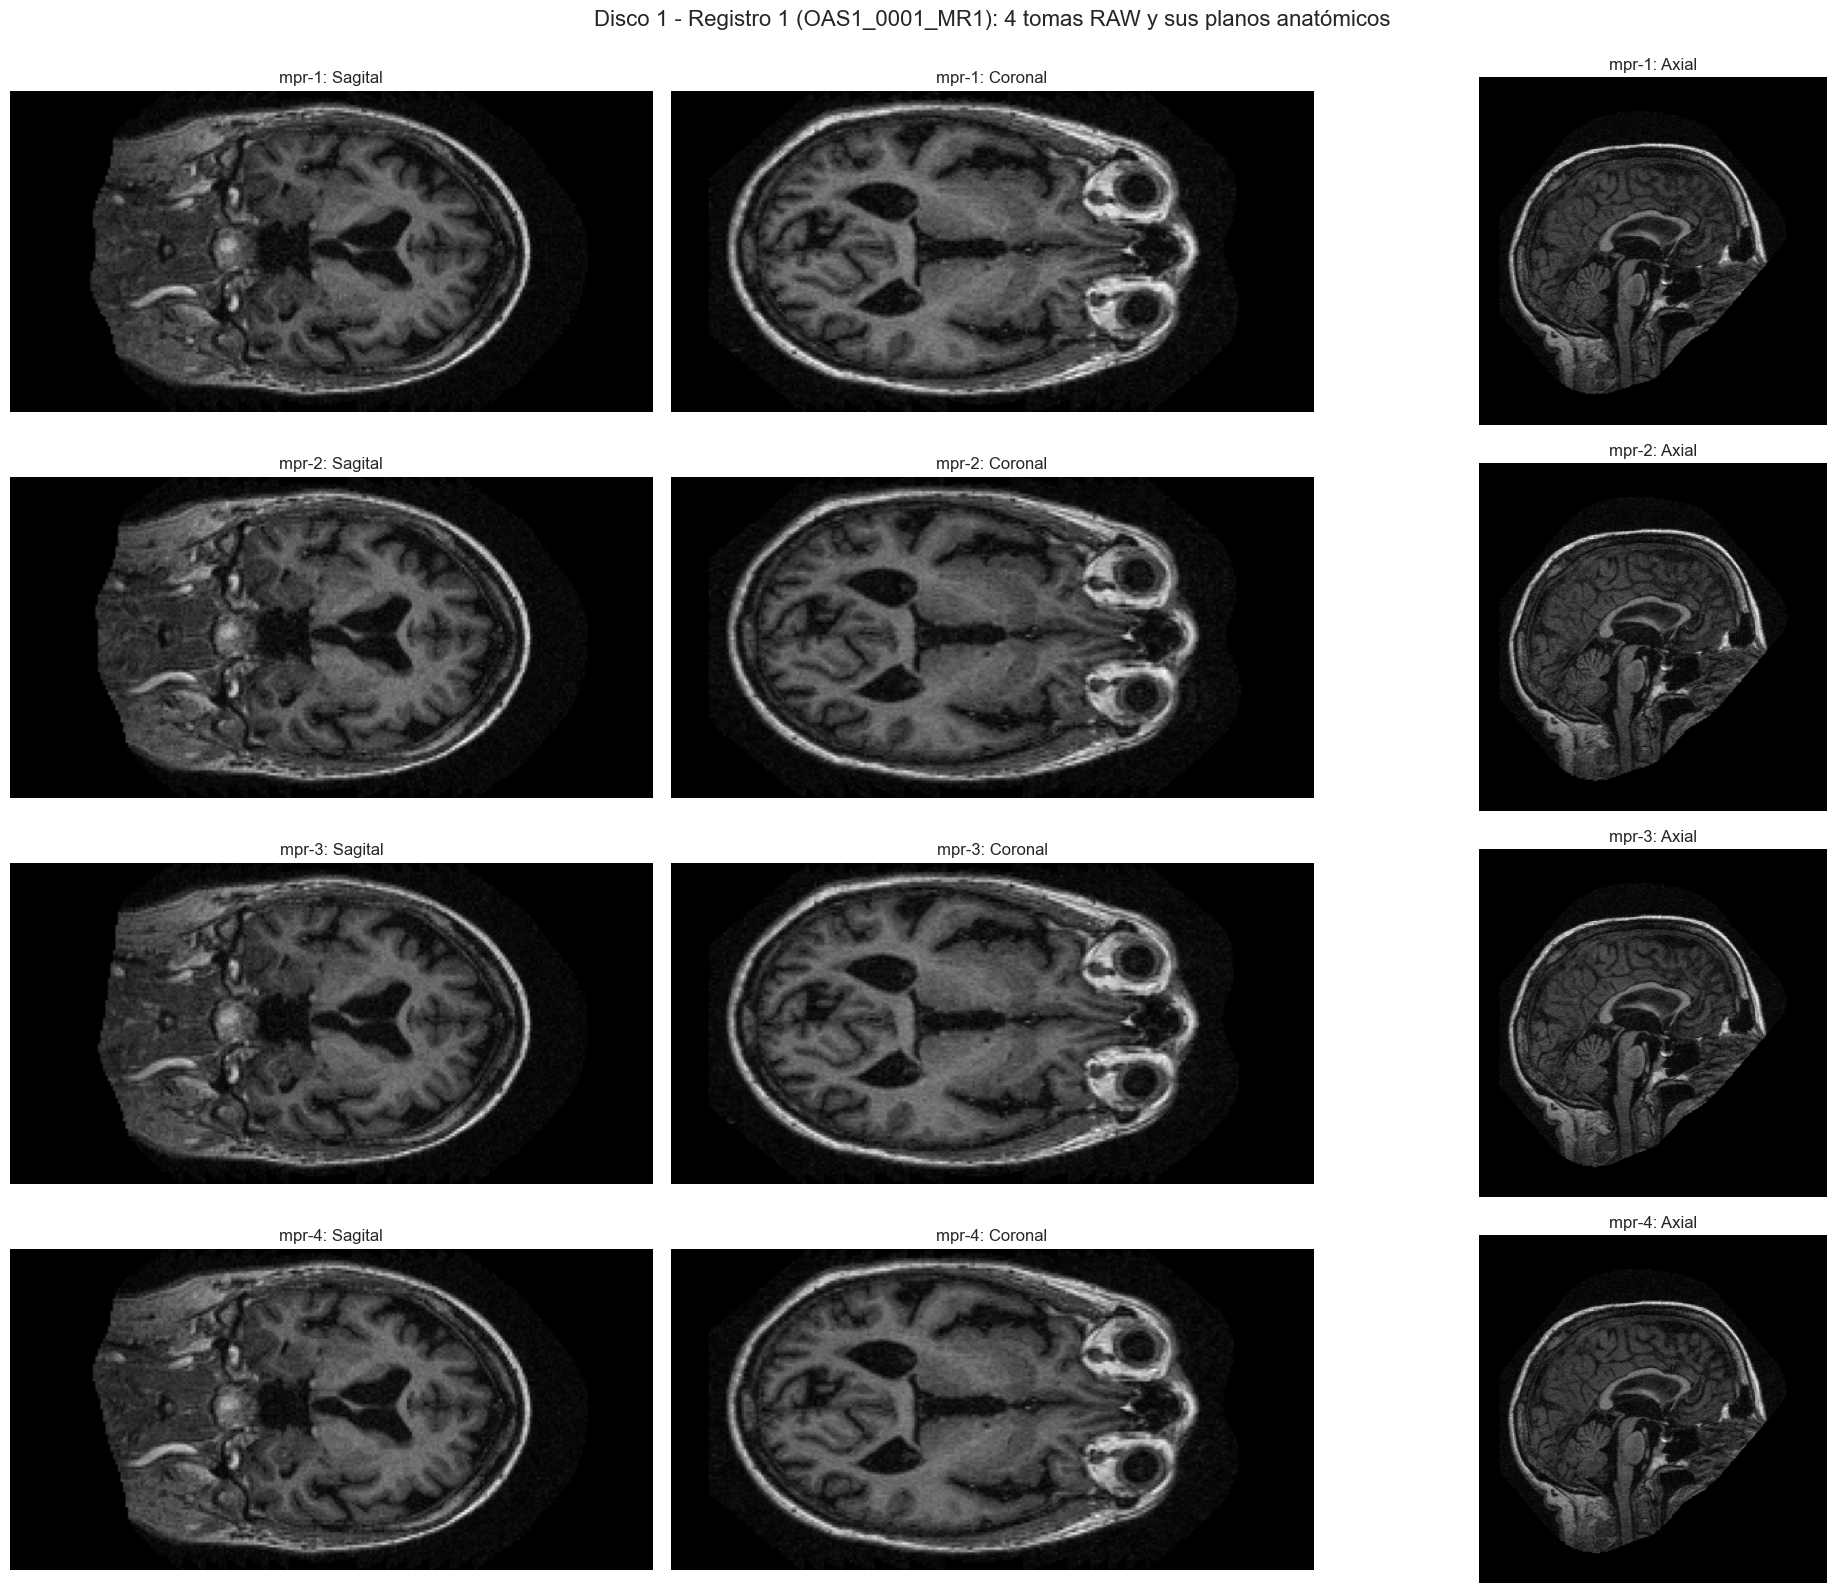


Información de cada volumen RAW:
Shape del volumen: (256, 256, 128)
Rango de intensidades: [0.0, 4095.0]
Resolución vóxel (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.25), np.float32(0.0))


In [113]:
BASE = os.path.join(DISC1_ROOT, 'OAS1_0001_MR1', 'RAW')

raw_files = ['OAS1_0001_MR1_mpr-1_anon.hdr', 
             'OAS1_0001_MR1_mpr-2_anon.hdr',
             'OAS1_0001_MR1_mpr-3_anon.hdr', 
             'OAS1_0001_MR1_mpr-4_anon.hdr']

fig = plt.figure(figsize=(20, 16))
fig.suptitle('Disco 1 - Registro 1 (OAS1_0001_MR1): 4 tomas RAW y sus planos anatómicos', fontsize=16, y=0.995)

for idx, filename in enumerate(raw_files):
    hdr_path = os.path.join(BASE, filename)
    img = nib.load(hdr_path)
    data = np.squeeze(img.get_fdata())
    
    cx, cy, cz = data.shape[0]//2, data.shape[1]//2, data.shape[2]//2
    
    # Plano Sagital
    ax1 = plt.subplot(4, 3, idx*3 + 1)
    ax1.imshow(np.squeeze(data[cx, :, :]).T, cmap='gray', origin='lower')
    ax1.set_title(f'mpr-{idx+1}: Sagital')
    ax1.axis('off')
    
    # Plano Coronal
    ax2 = plt.subplot(4, 3, idx*3 + 2)
    ax2.imshow(np.squeeze(data[:, cy, :]).T, cmap='gray', origin='lower')
    ax2.set_title(f'mpr-{idx+1}: Coronal')
    ax2.axis('off')
    
    # Plano Axial
    ax3 = plt.subplot(4, 3, idx*3 + 3)
    ax3.imshow(np.squeeze(data[:, :, cz]).T, cmap='gray', origin='lower')
    ax3.set_title(f'mpr-{idx+1}: Axial')
    ax3.axis('off')

plt.tight_layout()
plt.show()

img = nib.load(os.path.join(BASE, raw_files[0]))
data = np.squeeze(img.get_fdata())
print(f"\nInformación de cada volumen RAW:")
print(f"Shape del volumen: {data.shape}")
print(f"Rango de intensidades: [{data.min():.1f}, {data.max():.1f}]")
print(f"Resolución vóxel (mm): {img.header.get_zooms()}")

Se cargó el volumen MRI del sujeto OAS1_0001 en su versión RAW para explorar los datos en su versión original. El volumen tiene dimensiones de 256 × 256 × 128 vóxeles, con una resolución espacial de 1.0 × 1.0 × 1.25 mm por vóxel, y un rango de intensidades de 0 a 4095 debido a su codificación en 12 bits. Se visualizaron los tres planos anatómicos estándar para sus 4 tomas: sagital, coronal y axial, correspondientes a cortes perpendiculares a cada uno de los ejes espaciales del volumen. Esta visualización permite obtener información relevante del dato, identificar la orientación en la que se encuentran las imágenes y obtener una primera impresión visual de la calidad del dataset.

### 3.2 Visualización Imagen Promedio

La imagen es el resultado del promediado de las 4 adquisiciones RAW. Esta imagen logra que el ruido aleatorio se cancele al promediar múltiples adquisiciones, convirtiendo las 4 en una imagen más nítida con menos ruido granular y bordes más definidos.


Imagen Promedio:
Shape: (256, 256, 160)
Rango de intensidades: [0.0, 3866.0]
Resolución vóxel (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(0.0))


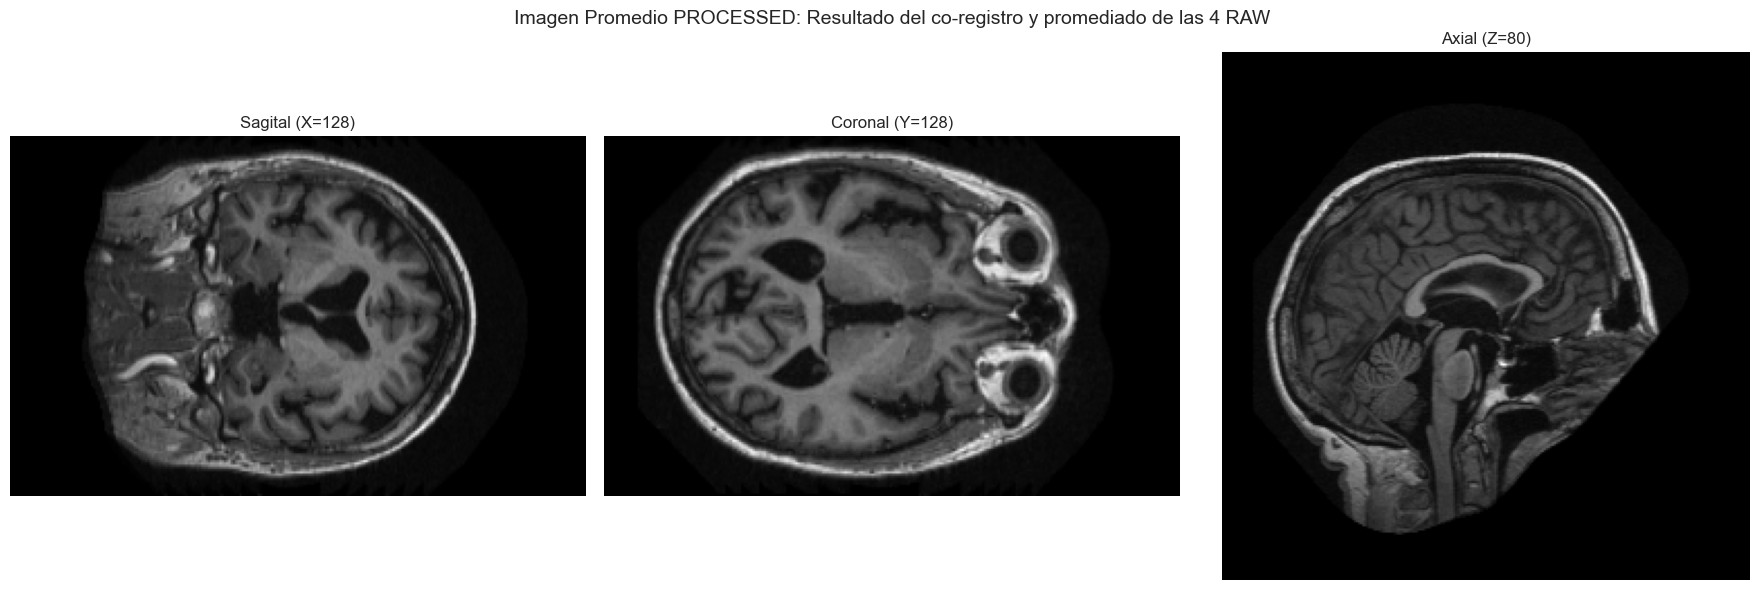

In [ ]:
processed_path = os.path.join(DISC1_ROOT, 'OAS1_0001_MR1', 'PROCESSED', 'MPRAGE', 'SUBJ_111', 
                               'OAS1_0001_MR1_mpr_n4_anon_sbj_111.hdr')

img_avg = nib.load(processed_path)
data_avg = np.squeeze(img_avg.get_fdata())

print(f"Imagen Promedio:")
print(f"Shape: {data_avg.shape}")
print(f"Rango de intensidades: [{data_avg.min():.1f}, {data_avg.max():.1f}]")
print(f"Resolución vóxel (mm): {img_avg.header.get_zooms()}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Imagen Promedio PROCESSED: promediado de las 4 RAW', fontsize=14)

cx, cy, cz = data_avg.shape[0]//2, data_avg.shape[1]//2, data_avg.shape[2]//2

axes[0].imshow(data_avg[cx, :, :].T, cmap='gray', origin='lower')
axes[0].set_title(f'Sagital (X={cx})')
axes[0].axis('off')

axes[1].imshow(data_avg[:, cy, :].T, cmap='gray', origin='lower')
axes[1].set_title(f'Coronal (Y={cy})')
axes[1].axis('off')

axes[2].imshow(data_avg[:, :, cz].T, cmap='gray', origin='lower')
axes[2].set_title(f'Axial (Z={cz})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### 3.3 Visualización de Procesamiento

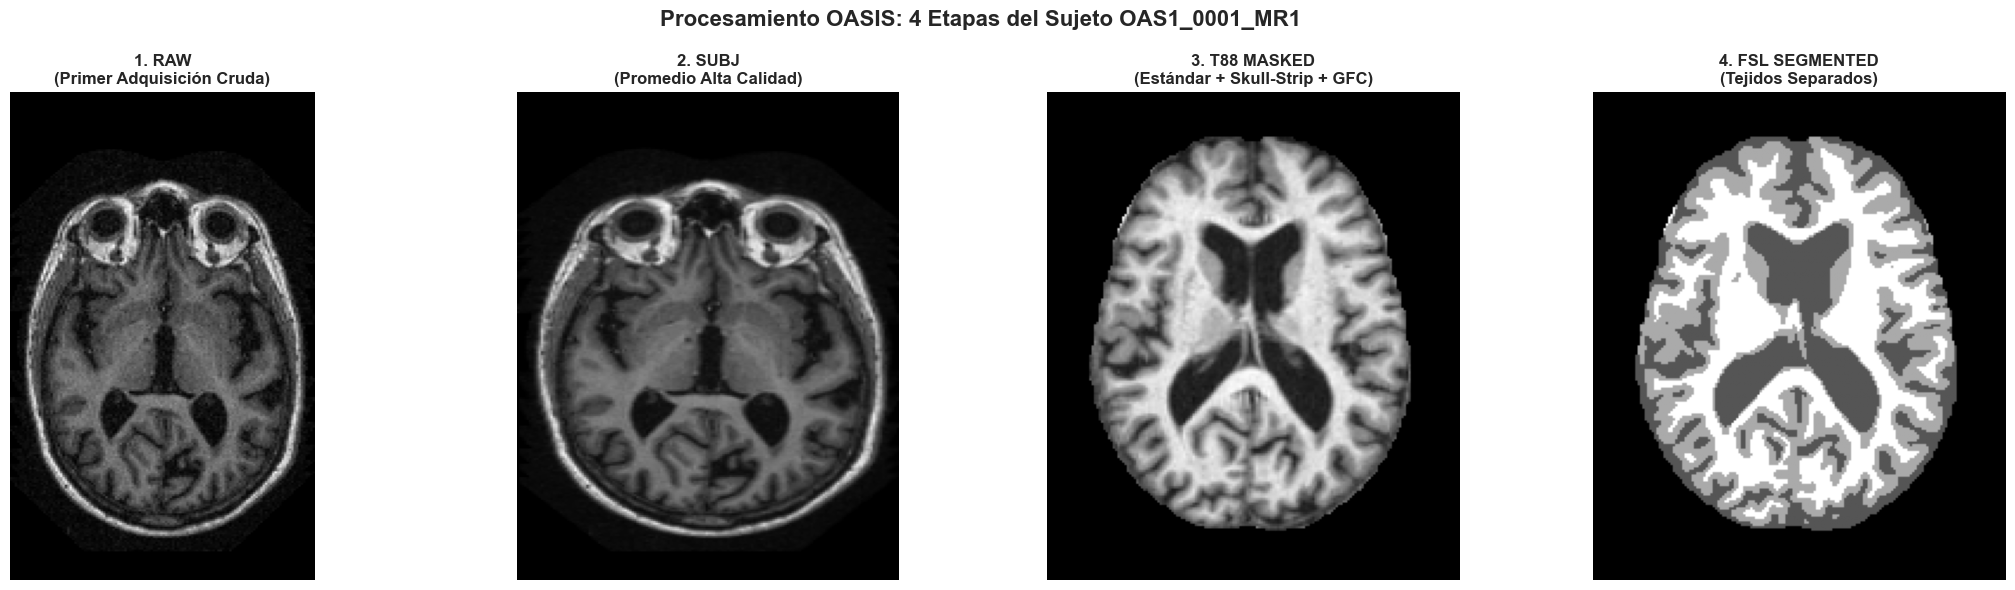

1. RAW shape:       (256, 256, 128) | Rango: [0, 4095]
2. SUBJ shape:      (256, 256, 160) | Rango: [0, 3866]
3. MASKED shape:    (176, 208, 176) | Rango: [0, 3126]
4. SEGMENTED shape: (176, 208, 176) | Clases únicas de tejido: [0. 1. 2. 3.]


In [18]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

BASE = os.path.join(DISC1_ROOT, 'OAS1_0001_MR1')

raw_path = os.path.join(BASE, 'RAW', 'OAS1_0001_MR1_mpr-1_anon.hdr')

subj_path = os.path.join(BASE, 'PROCESSED', 'MPRAGE', 'SUBJ_111', 
                         'OAS1_0001_MR1_mpr_n4_anon_sbj_111.hdr') 

masked_path = os.path.join(BASE, 'PROCESSED', 'MPRAGE', 'T88_111', 
                           'OAS1_0001_MR1_mpr_n4_anon_111_t88_masked_gfc.hdr')

segmented_path = os.path.join(BASE, 'FSL_SEG', 
                              'OAS1_0001_MR1_mpr_n4_anon_111_t88_masked_gfc_fseg.hdr')

img_raw = nib.load(raw_path)
img_subj = nib.load(subj_path)
img_masked = nib.load(masked_path)
img_seg = nib.load(segmented_path)

data_raw = np.squeeze(img_raw.get_fdata())
data_subj = np.squeeze(img_subj.get_fdata())
data_masked = np.squeeze(img_masked.get_fdata())
data_seg = np.squeeze(img_seg.get_fdata())

#  Extraer los cortes para visualización 2D
slice_idx_raw = data_raw.shape[1] // 2  
raw_slice = np.squeeze(data_raw[:, slice_idx_raw, :])

slice_idx_subj = data_subj.shape[1] // 2 
subj_slice = np.squeeze(data_subj[:, slice_idx_subj, :])

slice_idx_t88 = data_masked.shape[2] // 2 
masked_slice = np.squeeze(data_masked[:, :, slice_idx_t88]).T
seg_slice = np.squeeze(data_seg[:, :, slice_idx_t88]).T

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('Procesamiento OASIS: 4 Etapas del Sujeto OAS1_0001_MR1', fontsize=16, fontweight='bold')

axes[0].imshow(raw_slice, cmap='gray', origin='lower', aspect=0.8)
axes[0].set_title('1. RAW\n(Primer Adquisición Cruda)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(subj_slice, cmap='gray', origin='lower', aspect=0.8)
axes[1].set_title('2. SUBJ\n(Promedio Alta Calidad)', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(masked_slice, cmap='gray', origin='lower')
axes[2].set_title('3. T88 MASKED\n(Estándar + Skull-Strip + GFC)', fontsize=12, fontweight='bold')
axes[2].axis('off')

axes[3].imshow(seg_slice, cmap='gray', origin='lower', vmin=0, vmax=3)
axes[3].set_title('4. FSL SEGMENTED\n(Tejidos Separados)', fontsize=12, fontweight='bold')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print(f"1. RAW shape:       {data_raw.shape} | Rango: [{data_raw.min():.0f}, {data_raw.max():.0f}]")
print(f"2. SUBJ shape:      {data_subj.shape} | Rango: [{data_subj.min():.0f}, {data_subj.max():.0f}]")
print(f"3. MASKED shape:    {data_masked.shape} | Rango: [{data_masked.min():.0f}, {data_masked.max():.0f}]")
print(f"4. SEGMENTED shape: {data_seg.shape} | Clases únicas de tejido: {np.unique(data_seg)}")

Aqui podemos ver los tres estados del volumen MRI del sujeto OAS1_0001 según el pipeline de procesamiento del dataset OASIS. La imagen RAW corresponde a la adquisición #1 original sin ningún procesamiento, conteniendo el cráneo completo y tejidos extracraneales junto con ruido inherente de la adquisición. La imagen SUBJ es el promedio de las 4 tomas RAW. La imagen T88 MASKED es el resultado de aplicar skull stripping sobre la imagen promediada y registrarla al espacio estándar de Talairach , eliminando los tejidos no cerebrales y garantizando una alineación anatómica consistente entre sujetos. Por ultimo, La imagen SEGMENTED es el producto de la segmentación automática con FSL, donde cada vóxel se clasifica en materia gris, materia blanca o líquido cefalorraquídeo.

### 3.4 Histogramas de Procesamiento

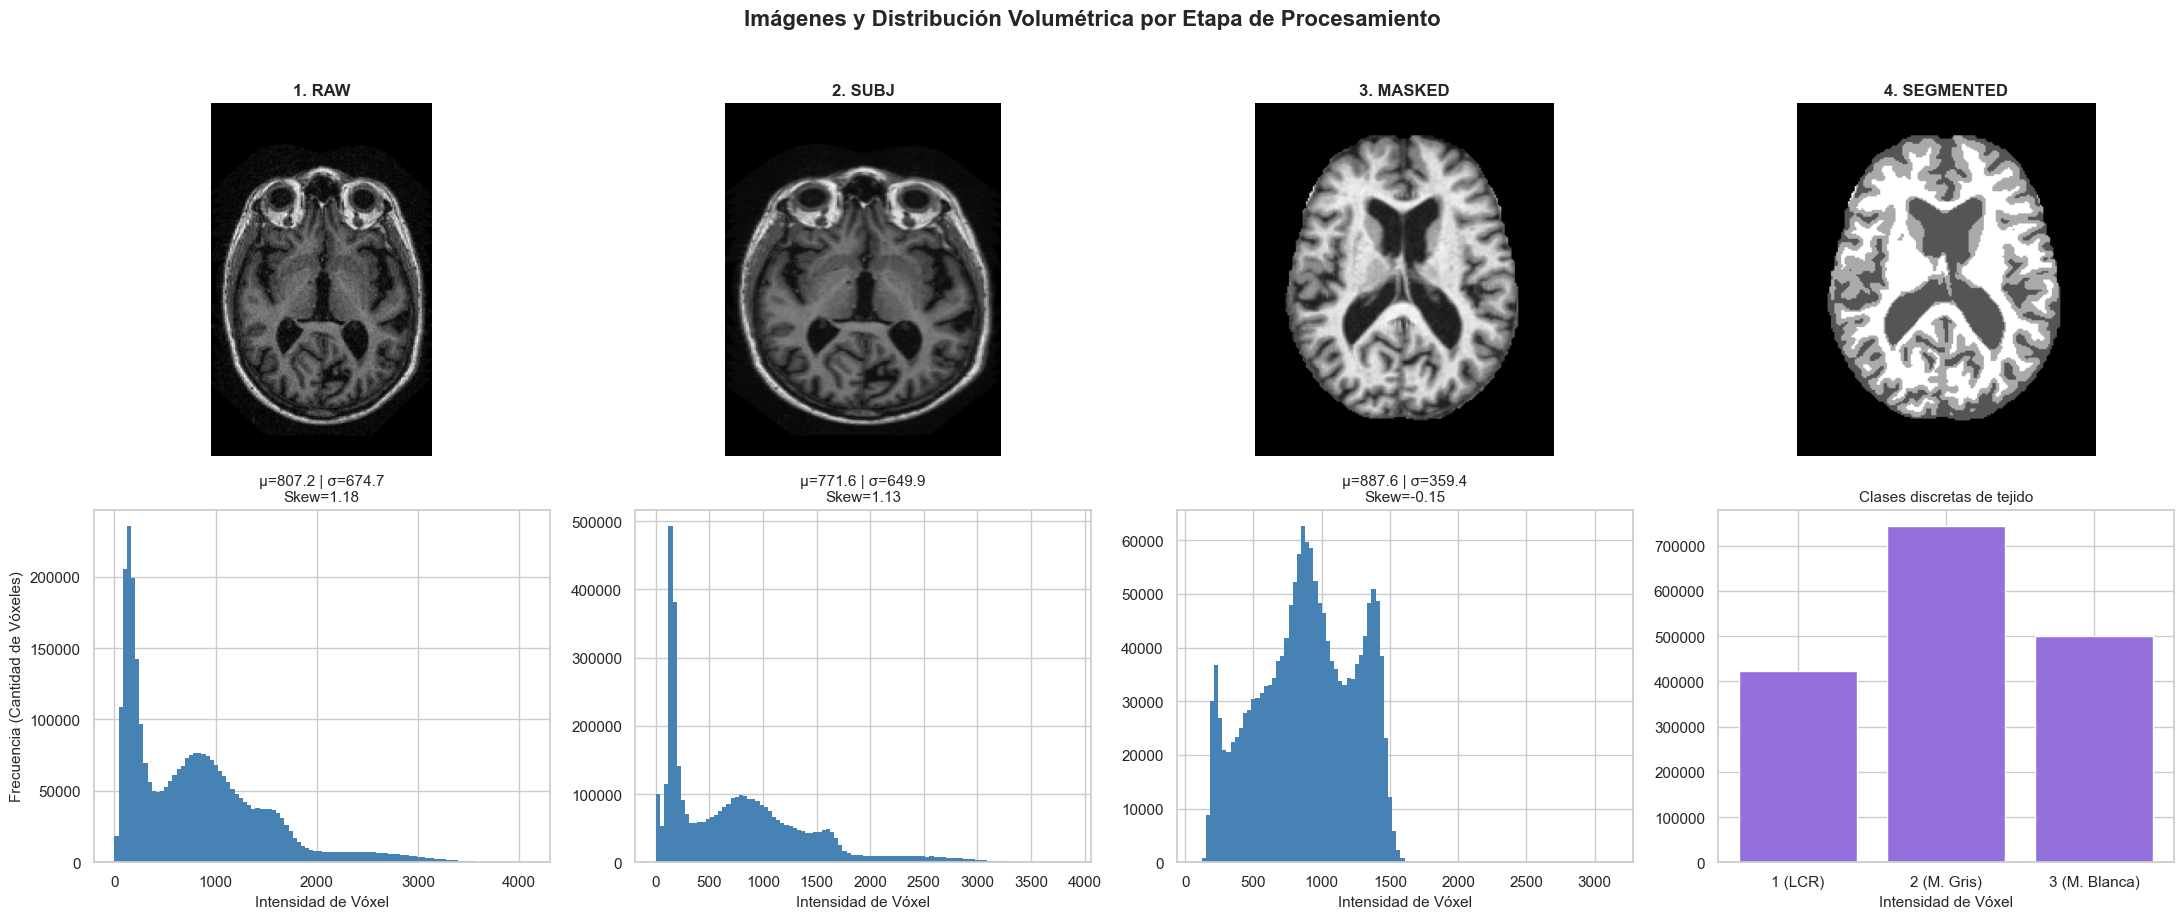

In [19]:

BASE = os.path.join(DISC1_ROOT, 'OAS1_0001_MR1')

paths = {
    '1. RAW': os.path.join(BASE, 'RAW', 'OAS1_0001_MR1_mpr-1_anon.hdr'),
    '2. SUBJ': os.path.join(BASE, 'PROCESSED', 'MPRAGE', 'SUBJ_111', 'OAS1_0001_MR1_mpr_n4_anon_sbj_111.hdr'),
    '3. MASKED': os.path.join(BASE, 'PROCESSED', 'MPRAGE', 'T88_111', 'OAS1_0001_MR1_mpr_n4_anon_111_t88_masked_gfc.hdr'),
    '4. SEGMENTED': os.path.join(BASE, 'FSL_SEG', 'OAS1_0001_MR1_mpr_n4_anon_111_t88_masked_gfc_fseg.hdr')
}

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('Imágenes y Distribución Volumétrica por Etapa de Procesamiento', fontsize=16, fontweight='bold', y=1.02)

for col, (titulo, path) in enumerate(paths.items()):
    img = nib.load(path)
    data = np.squeeze(img.get_fdata())
    
    if 'RAW' in titulo or 'SUBJ' in titulo:
        img_slice = data[:, data.shape[1] // 2, :]
        aspect_ratio = 0.8
    else:
        img_slice = data[:, :, data.shape[2] // 2].T
        aspect_ratio = 1.0

    ax_img = axes[0, col]
    if 'SEGMENTED' in titulo:
        ax_img.imshow(img_slice, cmap='gray', origin='lower', aspect=aspect_ratio, vmin=0, vmax=3)
    else:
        ax_img.imshow(img_slice, cmap='gray', origin='lower', aspect=aspect_ratio)
    ax_img.set_title(titulo, fontsize=12, fontweight='bold')
    ax_img.axis('off')

    ax_hist = axes[1, col]
    vol_no_zeros = data[data > 0] # Ignora el fondo negro en todas las etapas
    
    if 'SEGMENTED' in titulo:
        ax_hist.hist(vol_no_zeros, bins=[0.5, 1.5, 2.5, 3.5], color='mediumpurple', rwidth=0.8)
        ax_hist.set_xticks([1, 2, 3])
        ax_hist.set_xticklabels(['1 (LCR)', '2 (M. Gris)', '3 (M. Blanca)'])
        ax_hist.set_title("Clases discretas de tejido", fontsize=11)
    else:
        ax_hist.hist(vol_no_zeros, bins=100, color='steelblue', edgecolor='none')
        
        mu = np.mean(vol_no_zeros)
        std = np.std(vol_no_zeros)
        sk = skew(vol_no_zeros)
        
        ax_hist.set_title(f"μ={mu:.1f} | σ={std:.1f}\nSkew={sk:.2f}", fontsize=11)
        
    ax_hist.set_xlabel('Intensidad de Vóxel', fontsize=11)
    if col == 0:
        ax_hist.set_ylabel('Frecuencia (Cantidad de Vóxeles)', fontsize=11)

plt.tight_layout()
plt.show()

Se analizaron los histogramas de intensidad del sujeto OAS1_0001: RAW, SUBJ, T88 y SEGMENTADA, tomando el slice axial central de cada volumen. Para las versiones RAW y SUBJ es posible observar un histograma con una distribución asimétrica positiva, lo cual es esperado en este tipo de imágenes, ya que la mayoría de sus píxeles corresponden a tejidos de intensidad media-baja (materia gris) y una minoría corresponde a tejidos más brillantes (materia blanca). Para la versión T88 se obtiene un histograma similar al anterior, pero con una distribución más uniforme, resultado del registro al espacio estándar de Talairach. Por último, la versión SEGMENTADA presenta un histograma discreto con tres valores posibles: 1 = materia gris, 2 = materia blanca, 3 = LCR (líquido cefalorraquídeo).

## 4. Perfilamiento y características

#### A Continuación se analizarán de forma especifica las caracteristicas de un disco en particular, en este caso el primero


### 4.1 Estadísticas descriptivas por sujeto

In [132]:
all_hdrs = sorted(glob.glob(
    os.path.join(DATASET_ROOT, '**', 'RAW', '*mpr-1_anon.hdr'), recursive=True
))

print(f"Total de sujetos encontrados: {len(all_hdrs)}")

registros = []
for path in all_hdrs:
    partes = path.replace('\\', '/').split('/')
    sujeto = next((p for p in partes if p.startswith('OAS1_')), 'desconocido')    
    img_ras = nib.as_closest_canonical(nib.load(path))
    d = img_ras.get_fdata().squeeze()   
    px = d[d > 0].ravel()  
    
    registros.append({
        'Sujeto':    sujeto,
        'Shape':     d.shape,
        'Min':       round(d.min(), 1),
        'Max':       round(d.max(), 1),
        'Media':     round(np.mean(px), 1),
        'StdDev':    round(np.std(px), 1),
        'Skewness':  round(skew(px), 3),
    })

df = pd.DataFrame(registros)
print(df.to_string(index=False))

Total de sujetos encontrados: 436
       Sujeto           Shape  Min    Max  Media  StdDev  Skewness
OAS1_0349_MR1 (256, 256, 128)  0.0 4095.0  749.5   618.1     1.016
OAS1_0350_MR1 (256, 256, 128)  0.0 4095.0  845.5   570.6     0.732
OAS1_0351_MR1 (256, 256, 128)  0.0 4095.0  909.4   691.6     1.100
OAS1_0352_MR1 (256, 256, 128)  0.0 4095.0  875.5   742.9     1.532
OAS1_0353_MR1 (256, 256, 128)  0.0 4095.0  773.1   589.0     0.852
OAS1_0353_MR2 (256, 256, 128)  0.0 4095.0  701.0   537.8     0.867
OAS1_0354_MR1 (256, 256, 128)  0.0  458.0   87.8    63.0     1.023
OAS1_0355_MR1 (256, 256, 128)  0.0 4095.0  543.7   609.9     2.053
OAS1_0356_MR1 (256, 256, 128)  0.0 4084.0  893.9   722.3     1.125
OAS1_0357_MR1 (256, 256, 128)  0.0 4095.0  793.9   626.1     0.946
OAS1_0358_MR1 (256, 256, 128)  0.0 4095.0  878.6   654.4     0.908
OAS1_0359_MR1 (256, 256, 128)  0.0 4095.0  798.4   551.0     0.737
OAS1_0361_MR1 (256, 256, 128)  0.0 4095.0  779.9   591.6     0.856
OAS1_0362_MR1 (256, 256, 128

Se procesaron los 39 sujetos disponibles en el disco 1 del dataset OASIS, 
todos con dimensiones consistentes de 256 × 256 × 128 vóxeles y rango de 
intensidades de 0 a 4095. Para cada uno se calcularon las siguientes estadisticas de los pixeles de tejido excluyendo su fondo: media, desviación 
estándar, asimetría (skewness). La media de intensidades 
varía entre sujetos en el rango aproximado de 42 a 1009, reflejando diferencias en el brillo global de cada adquisición. La asimetría es positiva en todos los casos (valores entre 0.7 y 1.3), confirmando la distribución característica de MRI T1 con cola hacia intensidades altas. Se destacan dos sujetos atipicos (OAS1_0012 y OAS1_0019) con valores maximos fuera de lo comun, lo que sugiere posibles diferencias en los parametros de adquisicion o normzalicion.

### 4.2 Homogeneidad del dataset

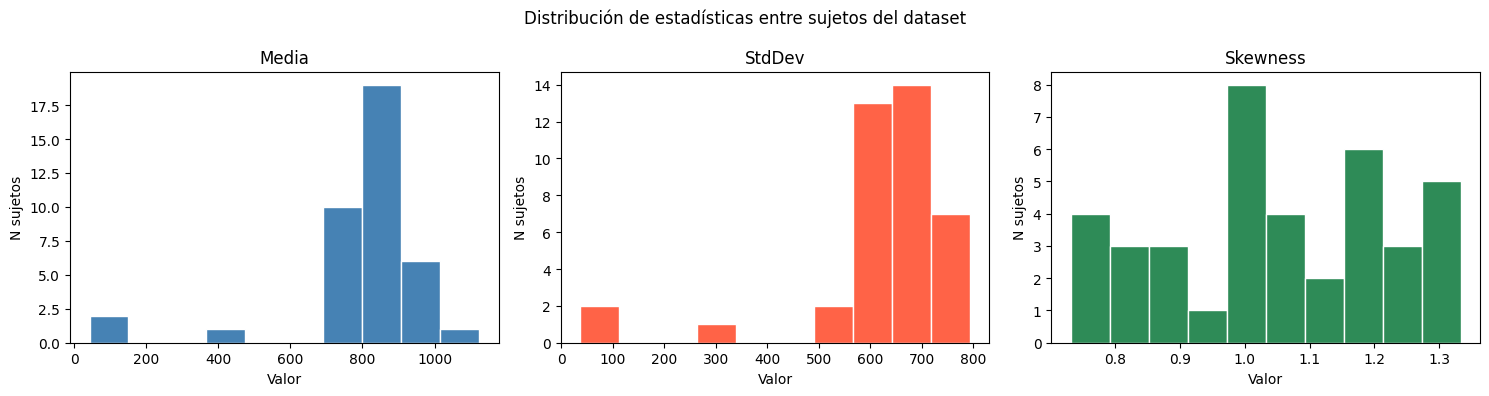

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribución de estadísticas entre sujetos del dataset')

for ax, col, color in zip(axes, ['Media', 'StdDev', 'Skewness'], ['steelblue','tomato','seagreen']):
    ax.hist(df[col], bins=10, color=color, edgecolor='white')
    ax.set_title(col); ax.set_xlabel('Valor'); ax.set_ylabel('N sujetos')


plt.tight_layout(); plt.show()

Ahora se evalua la homogeneidad del dataset, se analizó la distribución 
de tres estadísticas clave a través de los 39 sujetos disponibles en el disco 1. En cuanto a la media de intensidades, la mayoría de los sujetos se concentra en el rango de 800 a 900 unidades de intensidad, con algunos casos atípicos de valores muy bajos (cercanos a 0-200) que corresponden a los sujetos con rango dinámico reducido identificados anteriormente. La desviación estándar se agrupa predominantemente entre 600 y 700, lo que indica que la variabilidad interna de las imágenes es consistente entre sujetos y refleja un contraste similar entre tejidos en la mayoría de los casos. La asimetría  presenta valores entre 0.7 y 1.3 en todos los sujetos, con una concentración alrededor de 1.0, confirmando que el histograma de intensidades de las imágenes MRI T1 del dataset tiene una distribución asimétricamente positiva de forma consistente. 